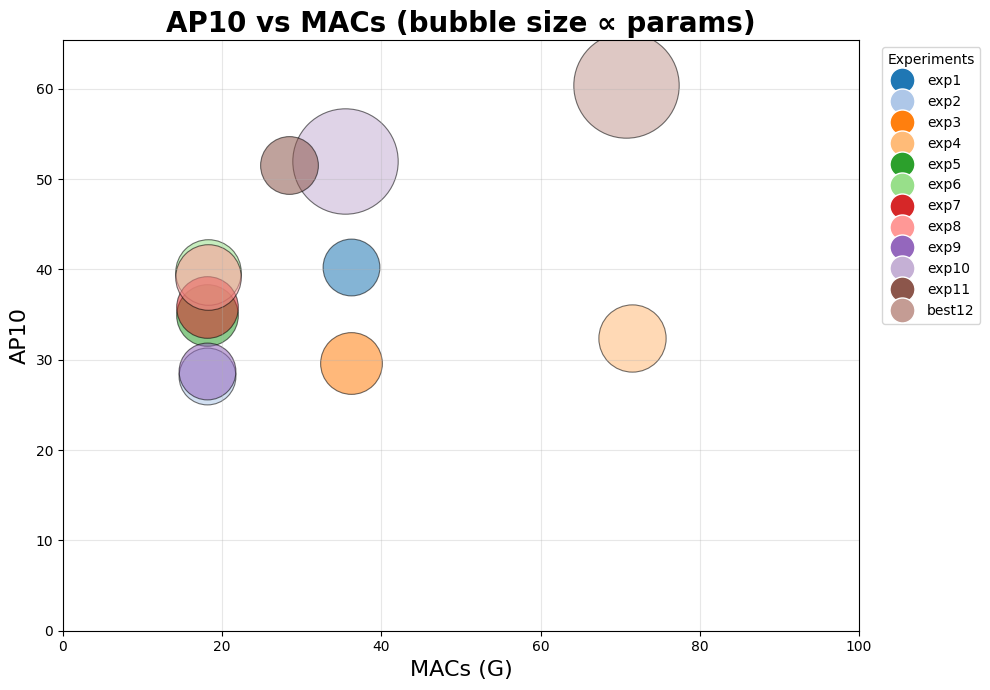

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Faltan por añadirse: 
url = "https://docs.google.com/spreadsheets/d/1FCRoQSso0D1cOMnjdgwXM45r_jAV_5qMdKh5jYK63nA/export?format=csv"
df = pd.read_csv(url)

# Falta añadir x3d_m (exp11) y luego NUESTRA MEJOR COMBINACION de clip len 100, stride 5 y alguna de las 3d cnns
df_sel = df[
    df["Experiment"].notna() &
    (df["Experiment"].astype(str).str.strip() != "")
].copy().reset_index(drop=True)

df_sel["exp_num"] = df_sel["Experiment"].str.extract(r'(\d+)').astype(int)
df_sel = df_sel.sort_values("exp_num").reset_index(drop=True)

df_sel["id"] = range(1, len(df_sel) + 1)

df_sel["TOTAL PARAMS"] = (
    df_sel["TOTAL PARAMS"].astype(str).str.replace(",", "", regex=False)
)
df_sel["TOTAL PARAMS"] = pd.to_numeric(df_sel["TOTAL PARAMS"], errors="coerce")
df_sel["MACs"] = pd.to_numeric(df_sel["MACs"], errors="coerce")
df_sel["AP10"] = pd.to_numeric(df_sel["AP10"], errors="coerce")

sizes = np.sqrt(df_sel["TOTAL PARAMS"]) 

cmap = plt.get_cmap("tab20")
colors = [cmap(i%20) for i in range(len(df_sel))]

plt.figure(figsize=(10, 7))

handles = []
labels = []

for i, row in df_sel.iterrows():
    plt.scatter(
        row["MACs"],
        row["AP10"],
        s=sizes.iloc[i],
        alpha=0.55,
        color=colors[i],
        edgecolors="black",
        linewidths=0.8
    )

plt.xlabel("MACs (G)", fontsize=16)
plt.ylabel("AP10", fontsize=16)
plt.title("AP10 vs MACs (bubble size ∝ params)", fontsize=20, fontweight='bold')

plt.xlim(0, 100)
plt.ylim(0, max(df_sel["AP10"]) + 5)

plt.grid(True, alpha=0.3)

legend_elements = []

for i, row in df_sel.iterrows():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=f'{row["Experiment"]}',
            markerfacecolor=colors[i],
            markersize=18
        )
    )

plt.legend(
    handles=legend_elements,
    title="Experiments",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
import wandb
import pandas as pd
import os

# 1. Setup API
api = wandb.Api()
# Replace with your actual path: "entity/project/sweep_id"
sweep_path = "c6-team2/C6-Week5/fw39h6sq"
sweep = api.sweep(sweep_path)
runs = sweep.runs

print(f"Starting raw export for {len(runs)} runs...")

all_run_data = []

for i, run in enumerate(runs):
    # Basic progress logging
    if (i + 1) % 10 == 0:
        print(f"Fetching run {i + 1}/{len(runs)}...")
    
    # Deep fetch to ensure we get the full config
    try:
        full_run = api.run("/".join(run.path))
        
        # Start with standard metadata
        run_dict = {
            "run_id": full_run.id,
            "run_name": full_run.name,
            "run_state": full_run.state,
            "run_url": full_run.url
        }
        
        # Add all Config parameters (prefixed for clarity)
        for k, v in full_run.config.items():
            run_dict[f"config_{k}"] = v
            
        # Add all Summary metrics (prefixed for clarity)
        for k, v in full_run.summary.items():
            if not k.startswith("_"): # Skip internal wandb metadata
                run_dict[f"metric_{k}"] = v
                
        all_run_data.append(run_dict)
        
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")

# 2. Create DataFrame
master_df = pd.DataFrame(all_run_data)

# 3. Save Raw CSV
os.makedirs("results", exist_ok=True)
output_file = "results/runs.csv"
master_df.to_csv(output_file, index=False)

print(f"\nDone! Raw data saved to {output_file}")
print(f"Total columns exported: {len(master_df.columns)}")

In [ ]:
import wandb
import pandas as pd



df = pd.read_csv("results/runs_extended.csv")

# Convert to numeric
cols = ['config_stride', 'config_clip_len', 'config_overlap', 'metric_test_AP10']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['metric_test_AP10'])

# --- Updated Helper Function ---
def get_stats(dataframe, group_cols):
    if dataframe.empty:
        return pd.DataFrame()
    
    # Adding 'count' to the aggregation list
    stats = dataframe.groupby(group_cols)['metric_test_AP10'].agg(['mean', 'std', 'count']).reset_index()
    
    # Renaming for clarity
    stats.columns = list(group_cols) + ['Mean AP10', 'Std Dev', 'Sample Count']
    return stats

# --- Generate Tables ---
table_1 = get_stats(df[df['config_clip_len'] == 50.0], ['config_stride'])
table_2 = get_stats(df[df['config_stride'] == 2.0], ['config_clip_len'])

ratios = [(1.0, 100.0), (2.0, 50.0), (3.0, 33.0), (4.0, 25.0), (5.0, 20.0)]
mask = df.apply(lambda x: (x['config_stride'], x['config_clip_len']) in ratios, axis=1)
table_3 = get_stats(df[mask], ['config_stride', 'config_clip_len'])

# Display Results
print("--- Table 1: config_stride Impact (config_clip_len=50) ---")
print(table_1)
print("\n--- Table 2: Clip Length Impact (config_stride=2) ---")
print(table_2)
print("\n--- Table 3: Fixed Ratio (Temporal Window) ---")
print(table_3)

table_1.to_csv("results/config_stride.csv", index=False)
table_2.to_csv("results/clip_length.csv", index=False)
table_3.to_csv("results/fixed_window.csv", index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- FONT SIZE SETTINGS ---
TITLE_SIZE = 25
LABEL_SIZE = 25
TICK_SIZE = 22
# --------------------------

# 1. Load the Master CSV
try:
    df = pd.read_csv("results/runs_extended.csv")
except FileNotFoundError:
    print("Error: sweep_results_full_raw.csv not found. Please run the export script first.")
    exit()

# 2. Setup Column Names (Based on the prefix logic from the export script)
STRIDE_COL = 'config_stride'
CLIP_COL = 'config_clip_len'
METRIC_COL = 'metric_test_AP10'

# 3. Clean and Convert Data
# Ensure numeric types; errors='coerce' turns non-numeric strings into NaN
for col in [STRIDE_COL, CLIP_COL, METRIC_COL]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where we are missing the target metric
df = df.dropna(subset=[METRIC_COL])

# 4. Define Experimental Slices
# Slice 1: Stride impact at fixed Clip Len 50
s1_df = df[df[CLIP_COL] == 50.0].groupby(STRIDE_COL)[METRIC_COL].agg(['mean', 'std']).reset_index()

# Slice 2: Clip Len impact at fixed Stride 2
s2_df = df[df[STRIDE_COL] == 2.0].groupby(CLIP_COL)[METRIC_COL].agg(['mean', 'std']).reset_index()

# Slice 3: Fixed Ratios (Stride/Clip_Len pairs)
ratios = [(1.0, 100.0), (2.0, 50.0), (3.0, 33.0), (4.0, 25.0), (5.0, 20.0)]
mask = df.apply(lambda x: (x[STRIDE_COL], x[CLIP_COL]) in ratios, axis=1)
s3_df = df[mask].copy()
# Create a string label for the plot: "Stride/Clip"
s3_df['label'] = s3_df[STRIDE_COL].astype(int).astype(str) + "/" + s3_df[CLIP_COL].astype(int).astype(str)
s3_stats = s3_df.groupby('label')[METRIC_COL].agg(['mean', 'std']).reset_index()
# Sort by stride to keep the ratios in order
s3_stats['stride_val'] = s3_stats['label'].apply(lambda x: int(x.split('/')[0]))
s3_stats = s3_stats.sort_values('stride_val')

# --- 5. VISUALIZATION 1: The 3-Panel Bar Plot ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# 1. Stride Plot (Blue)
axes[0].bar(s1_df[STRIDE_COL].astype(str), s1_df['mean'], yerr=s1_df['std'].fillna(0), 
            capsize=5, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title("Impact of Stride\n(Clip Len = 50)", fontweight='bold', fontsize=TITLE_SIZE)
axes[0].set_xlabel("Stride", fontsize=LABEL_SIZE)
axes[0].set_ylabel("Mean AP10", fontsize=LABEL_SIZE)
axes[0].tick_params(axis='both', labelsize=TICK_SIZE)

# 2. Clip Length Plot (Red)
axes[1].bar(s2_df[CLIP_COL].astype(str), s2_df['mean'], yerr=s2_df['std'].fillna(0), 
            capsize=5, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title("Impact of Clip Length\n(Stride = 2)", fontweight='bold', fontsize=TITLE_SIZE)
axes[1].set_xlabel("Clip Length", fontsize=LABEL_SIZE)
axes[1].tick_params(axis='both', which='major', labelsize=TICK_SIZE)

# 3. Fixed Ratios Plot (Green)
axes[2].bar(s3_stats['label'], s3_stats['mean'], yerr=s3_stats['std'].fillna(0), 
            capsize=5, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[2].set_title("Fixed Ratios\n(Stride / Clip Len = 2 / 50)", fontweight='bold', fontsize=TITLE_SIZE)
axes[2].set_xlabel("Ratio (S/C)", fontsize=LABEL_SIZE)
axes[2].tick_params(axis='both', which='major', labelsize=TICK_SIZE)

# Global layout adjustments
plt.tight_layout()
plt.savefig("analysis_subplots.png", dpi=300)

print("Successfully generated 'analysis_subplots.png' from master CSV.")